In [53]:
import numpy as np
import matplotlib.pyplot as plt

# define farfield animation
X_DIM = 256
Y_DIM = 256
Z_DIM = 256
TIME_STEPS = 120

TARGET_X_DIM = 32
TARGET_Y_DIM = 32
TARGET_Z_DIM = 32

farfield_zone = np.zeros((TIME_STEPS, X_DIM, Y_DIM, Z_DIM))

In [54]:
def get_target_path(steps, x_max, y_max, z_max):
    """
    Calculates the (x, y, z) coordinates for a target moving in a 
    horizontal square perimeter at the midpoint of Y.
    """
    path = []
    y_mid = y_max // 2
    
    offset = x_max / 16

    x_min = offset
    x_max_eff = x_max - offset - 1
    z_min = offset
    z_max_eff = z_max - offset - 1

    x_dist = x_max_eff - x_min
    z_dist = z_max_eff - z_min

    # divide total steps into 4 segments for the 4 sides of the square
    steps_per_side = steps // 4
    
    for t in range(steps):
        side = t // steps_per_side
        fraction = (t % steps_per_side) / steps_per_side
        
        if side == 0: # +x movement on front face
            x = x_min + int(fraction * x_dist)
            z = z_min
        elif side == 1: # +z movement on right face
            x = x_max_eff
            z = z_min + int(fraction * z_dist)
        elif side == 2: # -x movement on back face
            x = x_min + int((1 - fraction) * x_dist)
            z = z_max_eff
        else: # -z movement on left face back to starting position
            x = x_min
            z = z_min + int((1 - fraction) * z_dist)
            
        path.append((x, y_mid, z))
        
    return path

In [55]:
import matplotlib.animation as animation

path_coords = get_target_path(TIME_STEPS, X_DIM, Y_DIM, Z_DIM)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# set fixed axis limits - stop potential resizing during target travel
# matplotlib expects (width, height, depth) -> swap y/z
ax.set_xlim(0, X_DIM)
ax.set_zlim(0, Y_DIM)
ax.set_ylim(0, Z_DIM)

# add labels
ax.set_xlabel('X Voxel')
ax.set_ylabel('Z Voxel')
ax.set_zlabel('Y Voxel (Height)')
ax.set_title('3D Target Movement (GIF Generation)')

# draw wireframe at the midpoint to show the path's plane
xx, zz = np.meshgrid([0, X_DIM], [0, Z_DIM])
yy = np.full_like(xx, Y_DIM // 2)
ax.plot_wireframe(xx, zz, yy, color='gray', alpha=0.2)

# initialize the plot element that will move (the target voxel)
# we start with empty data []; 
# s (size)=150, c (color)='red' is color
target_scatter = ax.scatter([], [], [], c='red', s=150, marker='o', edgecolors='black')

def update(frame):
    """
    This function is called for every frame of the animation.
    'frame' is an integer counting from 0 to frames-1.
    """
    # get coordinate for the current time step
    x, y, z = path_coords[frame]
    
    # update the 3D scatter plot position.
    # matplotlib 3D scatter requires updating internal _offsets3d
    # wrap x, y, z in lists because scatter expects sequences
    # Swap z and y axis since - matplotlib expects second value to be depth, last to be height
    target_scatter._offsets3d = ([x], [z], [y])
    
    # update title for each time step
    ax.set_title(f'Target Movement - Time Step: {frame}/{TIME_STEPS}')
    
    # return updated display
    return target_scatter,

def visualize_path(path, x_dim, y_dim, z_dim):
    # extract x, z, y coordinates from the list of tuples
    # path is expected to be [(x1, z1, y1), (x2, z2, y2), ...]
    path_np = np.array(path)
    x_coords = path_np[:, 0]
    y_coords = path_np[:, 1]
    z_coords = path_np[:, 2]

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # plot target path
    ax.plot(x_coords, z_coords, y_coords, color='blue', label='Target Path', alpha=0.6)

    # plot the individual voxels as points
    # using a color map to show the progression of time
    colors = np.linspace(0, 1, len(path))
    scatter = ax.scatter(x_coords, z_coords, y_coords, c=colors, cmap='viridis', s=20)
    
    # add colorbar to indicate time step
    cbar = plt.colorbar(scatter, ax=ax, shrink=0.5, aspect=10)
    cbar.set_label('Time Progression (Start -> End)')

    # mark start and end points
    ax.scatter(x_coords[0], z_coords[0], y_coords[0], color='green', s=100, label='Start', marker='o')
    ax.scatter(x_coords[-1], z_coords[-1], y_coords[-1], color='red', s=100, label='End', marker='x')

    # set axis limits based on your defined DIMs
    ax.set_xlim(0, x_dim)
    ax.set_ylim(0, z_dim)
    ax.set_zlim(0, y_dim)

    # labels
    ax.set_xlabel('X Dimension')
    ax.set_ylabel('Z Dimension')
    ax.set_zlabel('Y Dimension')
    ax.set_title('3D Target Trajectory')
    ax.legend()

    plt.show()

print("Generating animation frames...")
# create animation object
# interval=50 -> 50ms time interval between frames
ani = animation.FuncAnimation(fig, update, frames=TIME_STEPS, interval=50, blit=False)

# save GIF using PillowWriter
output_filename = '3d_target_perimeter.gif'
print(f"Saving to {output_filename} (this might take a moment)...")
writer = animation.PillowWriter(fps=20)
ani.save(output_filename, writer=writer)

print("Done! GIF saved.")
plt.close(fig)

Generating animation frames...
Saving to 3d_target_perimeter.gif (this might take a moment)...
Done! GIF saved.


## Multiple trap animation

In [56]:
# sin wave path on y axis
# circular pattern in x/z plane
def get_corkscrew_path(steps, x_max, y_max, z_max, xz_loops=2, y_loops=1):
    """
    Calculates the (x, y, z) coordinates for a target moving in a 
    circular pattern in the x/z plane while oscillating on the y axis.
    """
    path = []
    
    x_mid = x_max / 2
    y_mid = y_max / 2
    z_mid = z_max / 2

    x_radius = (x_max / 2) - 1
    y_radius = (y_max / 2) - 1
    z_radius = (z_max / 2) - 1

    for t in range(steps):
        fraction = t / steps
        
        theta = fraction * xz_loops * 2 * np.pi
        x = x_mid + x_radius * np.cos(theta)
        z = z_mid + z_radius * np.sin(theta)

        phi = fraction * y_loops * 2 * np.pi
        y = y_mid - y_radius * np.cos(phi)
            
        # floor the float and make sure its in bounds
        x_val = max(0, min(x_max - 1, int(x)))
        y_val = max(0, min(y_max - 1, int(y)))
        z_val = max(0, min(z_max - 1, int(z)))

        path.append((x_val, y_val, z_val))
        
    return path


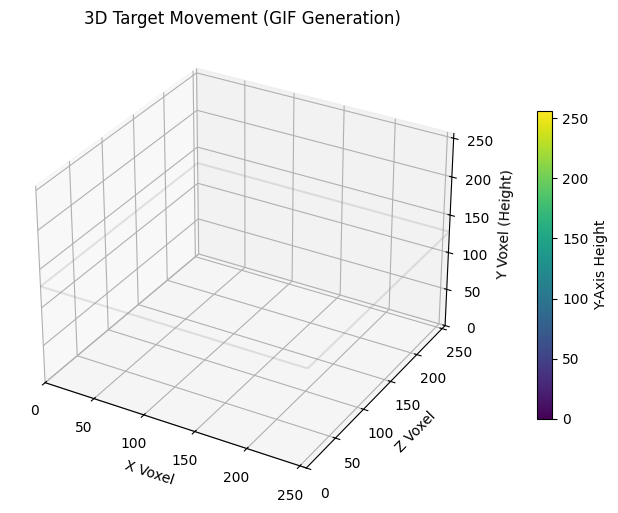

In [57]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# set fixed axis limits - stop potential resizing during target travel
ax.set_xlim(0, X_DIM)
ax.set_ylim(0, Z_DIM)
ax.set_zlim(0, Y_DIM)

# add labels
ax.set_xlabel('X Voxel')
ax.set_ylabel('Z Voxel')
ax.set_zlabel('Y Voxel (Height)')
ax.set_title('3D Target Movement (GIF Generation)')

# draw wireframe at the midpoint to show the path's plane
xx, zz = np.meshgrid([0, X_DIM], [0, Z_DIM])
yy = np.full_like(xx, Y_DIM // 2)
ax.plot_wireframe(xx, zz, yy, color='gray', alpha=0.2)

# create a color map to improve y axis visualization
cmap = cm.viridis
norm = mcolors.Normalize(vmin=0, vmax=Y_DIM)

# initialize the plot element that will move (the target voxel)
# we start with empty data []; 
# s (size)=150, c (color)='red' is color
target_one = ax.scatter([], [], [], s=150, marker='o', edgecolors='black')
target_two = ax.scatter([], [], [], s=150, marker='o', edgecolors='black')

# add color bar as legend for y axis value
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.5, pad=0.1)
cbar.set_label('Y-Axis Height')


In [58]:
def get_multitarget_paths():
    xy_path = get_target_path(TIME_STEPS, X_DIM, Y_DIM, Z_DIM)
    corkscrew_path = get_corkscrew_path(TIME_STEPS, X_DIM, Y_DIM, Z_DIM)

    return [xy_path, corkscrew_path]

multi_trap = get_multitarget_paths()

def update_2trap(frame):
    """
    This function is called for every frame of the animation.
    'frame' is an integer counting from 0 to frames-1.
    """
    # get coordinate for the current time step
    x1, y1, z1 = multi_trap[0][frame]
    x2, y2, z2 = multi_trap[1][frame]
    
    # update the 3D scatter plot position.
    # matplotlib 3D scatter requires updating internal _offsets3d
    # wrap x, y, z in lists because scatter expects sequences
    target_one._offsets3d = ([x1], [z1], [y1])
    target_two._offsets3d = ([x2], [z2], [y2])

    # set colors according to height for each target
    target_one_color = cmap(norm(y1))
    target_two_color = cmap(norm(y2))

    target_one.set_color(target_one_color)
    target_two.set_color(target_two_color)
    
    # update title for each time step
    ax.set_title(f'Target Movement - Time Step: {frame}/{TIME_STEPS}')
    
    # return updated display
    return target_scatter,

In [59]:
ani = animation.FuncAnimation(fig, update_2trap, frames=TIME_STEPS, interval=50, blit=False)

# save GIF using PillowWriter
output_filename = 'multitarget.gif'
print(f"Saving to {output_filename} (this might take a moment)...")
writer = animation.PillowWriter(fps=20)
ani.save(output_filename, writer=writer)

print("Done! GIF saved.")
plt.close(fig)

Saving to multitarget.gif (this might take a moment)...
Done! GIF saved.
